In [ ]:
!pip install -q easyocr tensorflow opencv-python

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1) (2).zip


In [ ]:
import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name,'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset Extracted")

BadZipFile: File is not a zip file

In [ ]:
import os
import cv2
import numpy as np

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
IMAGE_DIR = "dataset/images"
LABEL_DIR = "dataset/labels"

print("Images:",len(os.listdir(IMAGE_DIR)))
print("Labels:",len(os.listdir(LABEL_DIR)))

Images: 2083
Labels: 2021


In [ ]:
IMG_SIZE = 128

X=[]
y=[]

for file in os.listdir(IMAGE_DIR):

    if not file.endswith(".jpg"):
        continue

    img_path=os.path.join(IMAGE_DIR,file)

    label_path=os.path.join(
        LABEL_DIR,
        file.replace(".jpg",".txt")
    )

    img=cv2.imread(img_path)

    if img is None:
        continue

    img=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    img=img/255.0

    with open(label_path,'r') as f:
        line=f.readline().split()

        x=float(line[1])
        y_center=float(line[2])
        w=float(line[3])
        h=float(line[4])

    X.append(img)

    y.append([x,y_center,w,h])

X=np.array(X)
y=np.array(y)

print(X.shape)
print(y.shape)

(181, 128, 128)
(181, 4)


In [ ]:
X=X.reshape(-1,128,128,1)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model=Sequential()

model.add(
    Conv2D(
        16,
        (3,3),
        activation='relu',
        input_shape=(128,128,1)
    )
)

model.add(MaxPooling2D())

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(64,activation='relu'))

model.add(Dense(4,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,324 (7.05 MB)

 Trainable params: 1,848,324 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history=model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 479ms/step - loss: 0.0869 - mae: 0.2301 - val_loss: 0.0902 - val_mae: 0.2408
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - loss: 0.0450 - mae: 0.1651 - val_loss: 0.0476 - val_mae: 0.1708
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 533ms/step - loss: 0.0364 - mae: 0.1542 - val_loss: 0.0454 - val_mae: 0.1684
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 401ms/step - loss: 0.0303 - mae: 0.1338 - val_loss: 0.0469 - val_mae: 0.1498
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 349ms/step - loss: 0.0267 - mae: 0.1192 - val_loss: 0.0407 - val_mae: 0.1500


In [ ]:
model.save("vehicle_plate_detector.h5")

print("Model Saved")

Model Saved


In [ ]:
from google.colab import files

uploaded = files.upload()

test_image = list(uploaded.keys())[0]

print("Uploaded:", test_image)

Saving images.jpeg to images (2).jpeg
Uploaded: images (2).jpeg


In [ ]:
import cv2

img = cv2.imread(test_image)

if img is None:
    print("Image not found")
else:
    print("Image loaded successfully")
    print(img.shape)

Image loaded successfully
(364, 549, 3)


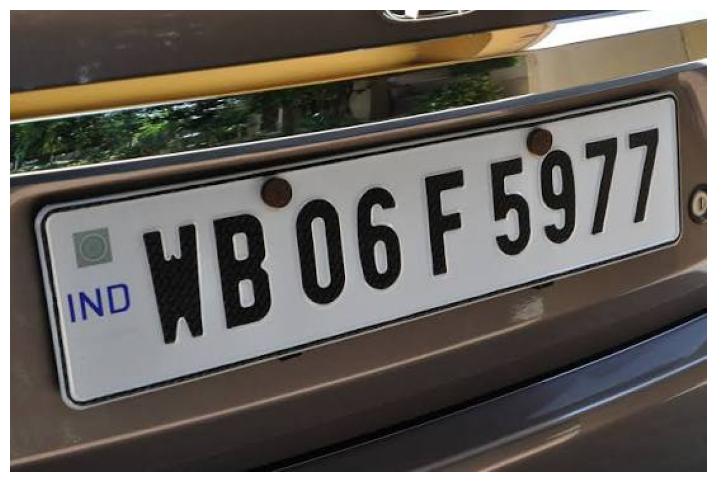

In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread(test_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import easyocr

reader = easyocr.Reader(['en'])

result = reader.readtext(test_image)

for r in result:
    print(r[1])

HB 06 F 5971]
IND


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
detected_plate = ""

for r in result:
    text = r[1]

    if len(text) >= 6:
        detected_plate = text

print("Detected Plate:", detected_plate)

Detected Plate: HB 06 F 5971]


In [ ]:
import re
import difflib

user_plate = input("Enter Vehicle Number : ")

user_plate = re.sub(r'[^A-Z0-9]', '', user_plate.upper())
ocr_plate = re.sub(r'[^A-Z0-9]', '', detected_plate.upper())

similarity = difflib.SequenceMatcher(
    None,
    user_plate,
    ocr_plate
).ratio()

print("User :", user_plate)
print("OCR  :", ocr_plate)
print("Match % :", round(similarity*100,2))

if similarity >= 0.70:
    print("✅ Correct Vehicle Number")
else:
    print("❌ Wrong Vehicle Number")

Enter Vehicle Number : HB06F5971
User : HB06F5971
OCR  : HB06F5971
Match % : 100.0
✅ Correct Vehicle Number
